#### Librerias

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import re
from textblob import TextBlob
from scipy import sparse
import joblib
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Variables

In [ ]:
MODELOS_PATH = "/content/drive/MyDrive/Trabajo práctico 3/modelos"

#### Carga de datos y modelos ya entrenados

In [ ]:
df_test = pd.read_pickle(f"{MODELOS_PATH}/test_limpio.pkl")

X_test_bow = sparse.load_npz(f"{MODELOS_PATH}/X_test_bow.npz")
X_test_tfidf = sparse.load_npz(f"{MODELOS_PATH}/X_test_tfidf.npz")

modelo_nb = joblib.load(f"{MODELOS_PATH}/modelo_nb_optimizado.pkl")
modelo_lr = joblib.load(f"{MODELOS_PATH}/modelo_lr_optimizado.pkl")

df_test.shape

(498, 7)

#### Subset binario

In [ ]:
mask_binario = df_test["polarity"].values != 2

X_test_bow_bin = X_test_bow[mask_binario]
X_test_tfidf_bin = X_test_tfidf[mask_binario]
y_test_bin = df_test["polarity"].values[mask_binario]

mask_binario.sum()

np.int64(359)

#### Limpieza liviana para TextBlob

A diferencia de text_limpio (usado para BoW/TF-IDF), acá NO se sacan stopwords
porque la lista de nltk incluye "not"/"no"/"nor" — eliminarlas rompería negaciones
como "not good", que TextBlob sí sabe interpretar correctamente si quedan intactas.

In [ ]:
def limpieza_textblob(texto):
    texto = re.sub(r'http\S+|www\S+', '', texto)
    texto = re.sub(r'@\w+', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df_test["text_textblob"] = df_test["text"].apply(limpieza_textblob)

#### Polaridad con TextBlob

In [ ]:
def sentyment_textblob(texto):
    blob = TextBlob(texto)
    return blob.sentiment.polarity

df_test["polaridad_textblob"] = df_test["text_textblob"].apply(sentyment_textblob)

#### Clasificación de la polaridad en clases (0=negativo, 2=neutral, 4=positivo)

In [ ]:
def clasificar_sentimiento(polaridad):
    if polaridad > 0:
        return 4
    elif polaridad < 0:
        return 0
    else:
        return 2

df_test["pred_textblob"] = df_test["polaridad_textblob"].apply(clasificar_sentimiento)

#### Evaluación completa de TextBlob (incluye neutrales)

In [ ]:
print(classification_report(
    df_test["polarity"], df_test["pred_textblob"],
    labels=[0, 2, 4], target_names=["Negativo", "Neutral", "Positivo"]
))

              precision    recall  f1-score   support

    Negativo       0.80      0.49      0.60       177
     Neutral       0.61      0.68      0.64       139
    Positivo       0.61      0.79      0.69       182

    accuracy                           0.65       498
   macro avg       0.67      0.65      0.64       498
weighted avg       0.68      0.65      0.65       498



Evaluado sobre el test completo con sus 3 clases, TextBlob muestra una capacidad
que nuestros modelos no tienen: puede predecir "neutral". Su desempeño global es
modesto, pero está jugando un partido más difícil (3 clases en vez de 2) y sin
haber visto un solo tweet de nuestro dataset.

#### Evaluación binaria — mismo subset que NB y LR

In [ ]:
pred_textblob_bin = df_test.loc[mask_binario, "pred_textblob"]

print(classification_report(
    y_test_bin, pred_textblob_bin,
    labels=[0, 4], target_names=["Negativo", "Positivo"]
))

              precision    recall  f1-score   support

    Negativo       0.86      0.49      0.62       177
    Positivo       0.73      0.79      0.76       182

   micro avg       0.77      0.64      0.70       359
   macro avg       0.79      0.64      0.69       359
weighted avg       0.79      0.64      0.69       359



En la comparación justa (mismos 359 tweets binarios), TextBlob rinde bastante peor
que nuestros modelos. Pero el detalle está en CÓMO falla: su precision se mantiene
razonable (~0.79) mientras el recall cae — porque en varios tweets predijo "neutral"
en vez de jugarse por positivo o negativo, y esos cuentan automáticamente como
error acá. TextBlob no está mal calibrado: es conservador. Prefiere no arriesgar
cuando la señal es débil, opción que NB y LR ni siquiera tienen.

#### Comparación final: NB vs LR vs TextBlob

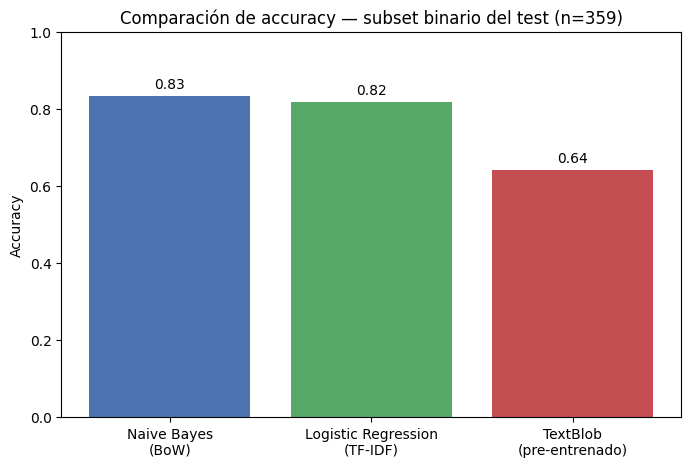

In [ ]:
pred_nb_bin = modelo_nb.predict(X_test_bow_bin)
pred_lr_bin = modelo_lr.predict(X_test_tfidf_bin)

acc_nb = accuracy_score(y_test_bin, pred_nb_bin)
acc_lr = accuracy_score(y_test_bin, pred_lr_bin)
acc_tb = accuracy_score(y_test_bin, pred_textblob_bin)

modelos = ["Naive Bayes\n(BoW)", "Logistic Regression\n(TF-IDF)", "TextBlob\n(pre-entrenado)"]
accuracies = [acc_nb, acc_lr, acc_tb]

plt.figure(figsize=(8,5))
barras = plt.bar(modelos, accuracies, color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Comparación de accuracy — subset binario del test (n=359)")
for barra, acc in zip(barras, accuracies):
    plt.text(barra.get_x() + barra.get_width()/2, acc + 0.02, f"{acc:.2f}", ha="center")
plt.show()

Conclusión de la comparación: los modelos entrenados específicamente con este tipo
de datos (0.83 y 0.82) superan con claridad al pre-entrenado genérico (0.64). Tiene
lógica — NB y LR vieron 1.6 millones de ejemplos de tweets reales con su jerga,
abreviaciones y estilo, mientras que TextBlob usa un diccionario genérico de inglés
que no está adaptado al lenguaje de Twitter.

#### Guardado de resultados

In [ ]:
df_test.to_pickle(f"{MODELOS_PATH}/test_con_textblob.pkl")